# 🛍️ Customer Review Intelligence Pipeline
## Sequential Pipeline Architecture using LangGraph + Groq + Tavily

---

### 🏗️ Architecture: Sequential Pipeline (A → B → C → END)

```
START
  ↓
Scraper Agent       → collects raw reviews from the web
  ↓
Sentiment & Theme Agent → analyzes tone, extracts recurring themes
  ↓
Insights Report Agent  → generates actionable product improvement report
  ↓
END
```

**What each agent does:**
| Step | Agent | Input | Output |
|------|-------|-------|--------|
| 1 | Scraper Agent | Product name | Raw review text from web |
| 2 | Sentiment & Theme Agent | Raw reviews | Structured sentiment + themes |
| 3 | Insights Report Agent | Structured analysis | Actionable product report |

---

### 🔄 How Sequential Pipeline Differs from Other Architectures

```
Supervisor (Projects 1 & 2):    Router (Projects 3 & 4):    Sequential Pipeline (THIS):

Supervisor decides order         Router picks ONE agent        FIXED order, ALL run
Can loop back                    No loop — one shot            No branching, no loops
Dynamic flow                     Dynamic selection             Deterministic flow

A → Supervisor → B               Router → A                    A → B → C → END
B → Supervisor → C                      → B (only one)
C → Supervisor → END                    → C
```

**Key insight about Sequential Pipeline:**
- Every agent ALWAYS runs — no skipping
- Each agent's output becomes the EXACT input of the next agent
- The graph is `START → A → B → C → END` — simplest possible LangGraph structure
- No Supervisor needed — LangGraph's `add_edge` handles ordering

### 🔁 Real Data Transformation in This Pipeline

```
"Apple AirPods Pro"           ← user input
        ↓  Scraper Agent
"Review 1: Great noise cancel  ← raw messy text from web
 Review 2: Battery died fast
 Review 3: Worth every penny..."
        ↓  Sentiment & Theme Agent
{ positive: 68%, negative: 32%  ← structured analysis
  themes: [noise_cancellation,
           battery_life, price] }
        ↓  Insights Report Agent
"## Product Intelligence Report  ← final actionable report
 ### Top Strengths: ...
 ### Critical Issues: ...
 ### Recommended Actions: ..."  
```

**Each step transforms data from messy → structured → actionable.**

---

### Step 0: Loading Environment & Liabraries

In [1]:
from dotenv import load_dotenv
load_dotenv()
import os

In [2]:
# pydantic: For structured data validation
from pydantic import BaseModel, Field

# LangChain components for prompts and parsing
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.output_parsers import PydanticOutputParser

# LangChain message types
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage

# LangChain runnable
from langchain_core.runnables import RunnablePassthrough

# LangGraph
from langgraph.graph import StateGraph, END

c:\Users\HP\anaconda3\envs\fresh_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Step 1: Loading/Initializing LLM

In [3]:
from langchain_groq import ChatGroq

# Groq automatically reads GROQ_API_KEY from environment variables

model = ChatGroq(
    model="openai/gpt-oss-120b",   # or llama-3.3-70b-versatile
    temperature=0.7
)

llm = model

In [4]:
# ---- TEST ----
try:
    response = llm.invoke("Say hello in one sentence.")
    print("✅ Groq LLM initialized successfully")
    print("Response:", response.content)

except Exception as e:
    print("❌ Groq LLM initialization failed")
    print(e)

✅ Groq LLM initialized successfully
Response: Hello! I hope you're having a wonderful day.


## 📋 Step 2 — Shared State Definition

### State Design Philosophy Across All 4 Architectures

```
Supervisor state:           Router state:            Sequential state (THIS):
  Many optional fields        Few fields               Fields fill one-by-one
  Supervisor controls order   Route + answer           Strict left-to-right fill
  next_agent field needed     No ordering needed       No next_agent needed!

  company_name                query                    product_name
  financial_data ← Agent 1    route     ← Router       raw_reviews    ← Agent 1
  news_data      ← Agent 2    answer    ← Specialist    sentiment_data ← Agent 2
  memo           ← Agent 3                              final_report   ← Agent 3
  next_agent     ← Supervisor                           messages
  messages
```

**Sequential state is the cleanest** — each field is filled exactly once,
in a predictable order, by a specific agent. No routing logic needed.

In [5]:
from typing import TypedDict, Optional


class ReviewPipelineState(TypedDict):
    """
    Shared state for the Customer Review Intelligence Pipeline.

    In Sequential Architecture, state is like an assembly line:
    - Each station (agent) receives the partially-built product
    - Adds its own piece
    - Passes it to the next station
    - No station needs to know about others — just its input and output

    Field lifecycle:
      product_name   → set by user at START (never changes)
      raw_reviews    → filled by Scraper Agent (Step 1)
      sentiment_data → filled by Sentiment Agent (Step 2, reads raw_reviews)
      final_report   → filled by Report Agent (Step 3, reads sentiment_data)
    """

    # --- User Input ---
    # Product name the user wants to analyze
    # e.g. "Apple AirPods Pro", "Samsung Galaxy S24", "Nike Air Max"
    product_name: str

    # --- Step 1 Output: Scraper Agent ---
    # Raw review text collected from web searches
    # Messy, unstructured, contains noise — that's OK, Agent 2 cleans it
    raw_reviews: Optional[str]

    # --- Step 2 Output: Sentiment & Theme Agent ---
    # Structured analysis: sentiment scores, recurring themes, pain points
    # This is the "processed" form that Agent 3 uses to write the report
    sentiment_data: Optional[str]

    # --- Step 3 Output: Insights Report Agent ---
    # Final actionable product intelligence report
    # This is the deliverable — what the product team actually reads
    final_report: Optional[str]

    # --- Metadata ---
    # Total number of reviews collected (tracked for report credibility)
    review_count: Optional[int]

    # Running log of pipeline events
    messages: list


print("✅ ReviewPipelineState defined!")
print("   Fields:", list(ReviewPipelineState.__annotations__.keys()))
print()
print("   Data flow:")
print("   product_name → [Scraper] → raw_reviews → [Sentiment] → sentiment_data → [Report] → final_report")

✅ ReviewPipelineState defined!
   Fields: ['product_name', 'raw_reviews', 'sentiment_data', 'final_report', 'review_count', 'messages']

   Data flow:
   product_name → [Scraper] → raw_reviews → [Sentiment] → sentiment_data → [Report] → final_report


## 🌐 Step 3 — Step 1: Scraper Agent

**Role:** Search the web for real customer reviews about the product.

### Search Strategy — 4 Targeted Queries
Instead of one generic search, we run **4 focused queries** to maximize coverage:
```
Query 1: General reviews    → "[product] review 2024" (overall sentiment)
Query 2: Negative reviews   → "[product] problems complaints" (pain points)
Query 3: Comparison reviews → "[product] vs alternatives" (competitive gaps)
Query 4: Long-term reviews  → "[product] after 6 months" (durability issues)
```
This 4-angle approach surfaces different types of feedback that a single
search would miss — especially long-term and competitive insights.

### Agent Role
The LLM here acts as a **data curator** not an analyst:
- Remove obvious spam / irrelevant results
- Deduplicate similar reviews  
- Preserve original reviewer language (don't paraphrase yet!)
- Count and label reviews for downstream agents

In [7]:
from tavily import TavilyClient
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage

def scraper_agent(state: dict) -> dict:
    """
    Pipeline Step 1: Collect raw customer reviews from the web.

    Two-phase approach:
    Phase 1 → Tavily tool: fetch raw web results (4 targeted searches)
    Phase 2 → LLM: curate, deduplicate, and structure the raw results

    WHY two phases?
    - Tavily returns messy web content (HTML artifacts, irrelevant text)
    - LLM can identify which snippets are actual reviews vs. marketing copy
    - Separation of concerns: tool fetches, LLM curates

    Args:
        state: ReviewPipelineState — reads 'product_name'

    Returns:
        Dict with 'raw_reviews' and 'review_count' filled in
    """
    print("\n" + "="*60)
    print("🌐 SCRAPER AGENT (Step 1/3): Collecting reviews...")
    print("="*60)

    product = state["product_name"]
    print(f"   Product: {product}")

    # Initialize Tavily client
    client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

    # ----------------------------------------------------------------
    # PHASE 1: Run 4 targeted web searches
    # Each search angle captures a DIFFERENT type of customer feedback
    # ----------------------------------------------------------------
    search_queries = [
        # Angle 1: General recent reviews — overall market sentiment
        (f"{product} customer review 2024 2025",
         "GENERAL REVIEWS"),

        # Angle 2: Complaints & problems — surfaces pain points loudest
        # Unhappy customers write longer, more detailed reviews
        (f"{product} problems complaints issues negative review",
         "NEGATIVE / COMPLAINTS"),

        # Angle 3: Competitor comparisons — reveals feature gaps
        # "X vs Y" reviews are gold for product teams
        (f"{product} vs alternative comparison worth it",
         "COMPARISON / VS"),

        # Angle 4: Long-term ownership reviews — durability & regret
        # First impressions differ from 6-month usage experience
        (f"{product} long term review after months ownership experience",
         "LONG-TERM USE"),
    ]

    all_raw_content = []

    for query, label in search_queries:
        print(f"   Searching: [{label}]...")
        try:
            results = client.search(
                query=query,
                search_depth="advanced",  # deeper crawl = better review content
                max_results=5,
                include_answer=True       # Tavily's AI summary as bonus context
            )

            all_raw_content.append(f"\n{'='*40}\n{label}\n{'='*40}")

            # Tavily's auto-summary gives a quick overview per search
            if results.get("answer"):
                all_raw_content.append(f"Summary: {results['answer']}\n")

            # Individual search result snippets
            for i, r in enumerate(results.get("results", []), 1):
                all_raw_content.append(
                    f"[{label}-{i}]\n"
                    f"Source : {r.get('url', 'N/A')}\n"
                    # content = full article text from Tavily, not just snippet
                    f"Content: {r.get('content', '')[:500]}\n"
                )

        except Exception as e:
            # Don't crash the whole pipeline if one search fails
            # Log it and continue — downstream agents handle partial data
            print(f"   ⚠️  Search failed for [{label}]: {e}")
            all_raw_content.append(f"\n[{label}]: Search failed — {str(e)}")

    combined_raw = "\n".join(all_raw_content)
    print(f"   Raw data collected: {len(combined_raw)} chars across 4 search angles")

    # ----------------------------------------------------------------
    # PHASE 2: LLM curates and structures the raw search content
    # Goal: extract ONLY actual customer review content, remove noise
    # ----------------------------------------------------------------
    # llm = ChatGroq(
    #     model="llama-3.3-70b-versatile",
    #     temperature=0,      # 0 = deterministic extraction, not creative
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    messages = [
        SystemMessage(content="""You are a data curation specialist.
Your job is to extract and organize genuine customer review content from raw web search results.

WHAT TO INCLUDE:
- Direct customer quotes and opinions
- Specific product praise or complaints
- Comparisons customers make to other products
- Long-term usage observations
- Recurring themes you notice across multiple sources

WHAT TO EXCLUDE:
- Marketing copy and promotional language
- Sponsored content
- Generic product descriptions
- Duplicate or near-identical points
- Navigation text, headers, ads

OUTPUT FORMAT:
Organize extracted reviews into these 4 categories:

## POSITIVE FEEDBACK
[List genuine positive customer quotes/opinions — preserve original language]

## NEGATIVE FEEDBACK  
[List genuine complaints and problems — be specific, not vague]

## COMPARISON INSIGHTS
[What customers say when comparing to alternatives]

## LONG-TERM OBSERVATIONS
[What customers report after extended use]

## REVIEW METADATA
Estimated total distinct reviews processed: [N]
Most mentioned product aspects: [list top 5]"""),

        HumanMessage(content=f"""
Product: {product}

Please extract and organize genuine customer reviews from this raw web content:

{combined_raw}
""")
    ]

    print("   Asking LLM to curate and structure raw reviews...")
    response    = llm.invoke(messages)
    curated     = response.content

    # Try to extract the review count from the metadata section
    # This is used later in the report for credibility ("based on N reviews")
    review_count = 0
    for line in curated.split("\n"):
        if "distinct reviews processed" in line.lower():
            # Extract number from line like "Estimated total distinct reviews processed: 47"
            parts = line.split(":")
            if len(parts) > 1:
                try:
                    review_count = int(parts[-1].strip().split()[0])
                except (ValueError, IndexError):
                    review_count = 20  # Fallback estimate

    if review_count == 0:
        review_count = 20  # Reasonable default if extraction fails

    print(f"   ✅ Scraper Agent complete!")
    print(f"      Reviews curated: ~{review_count}")
    print(f"      Curated content: {len(curated)} chars")

    # Return ONLY the fields this agent is responsible for filling
    # LangGraph merges this dict back into the full state
    return {
        "raw_reviews":  curated,       # → consumed by Sentiment Agent (Step 2)
        "review_count": review_count,  # → used in final report for credibility
        "messages": state["messages"] + [
            {"role": "scraper_agent",
             "content": f"[Step 1/3] Reviews collected for {product}. "
                        f"~{review_count} reviews from 4 search angles."}
        ]
    }


print("✅ Scraper Agent (Step 1) defined!")
print()
print("   Search strategy: 4 angles × 5 results = up to 20 review sources")
print("   LLM role: data curator (extract signal, remove noise)")

✅ Scraper Agent (Step 1) defined!

   Search strategy: 4 angles × 5 results = up to 20 review sources
   LLM role: data curator (extract signal, remove noise)


## 📊 Step 4 — Step 2: Sentiment & Theme Agent

**Role:** Transform curated raw reviews → structured sentiment scores + theme analysis

### What This Agent Produces
This is the **analytical core** of the pipeline. It takes messy review text and produces
a structured analysis that the Report Agent (Step 3) can use directly.

```
INPUT (from Scraper Agent):         OUTPUT (for Report Agent):
"Great noise cancellation!"    →    Overall Sentiment: 71% Positive
"Battery died after 6 months"  →    Theme 1: Noise Cancellation (Positive, High frequency)
"Worth every penny"            →    Theme 2: Battery Life (Negative, High frequency)
"ANC better than Sony"         →    Theme 3: Price/Value (Mixed, Medium frequency)
"Fit is uncomfortable"         →    NPS Score: ~42
                                    Top Pain Point: Battery durability
                                    Top Strength: Audio quality
```

### Why a Separate Agent for This?
Sentiment analysis is a **different cognitive task** from scraping and from writing.
Separating it means:
- We can tune the prompt specifically for analytical precision
- The output format can be optimized for the Report Agent's needs
- If this step needs improvement, we change only this agent

In [8]:
def sentiment_theme_agent(state: dict) -> dict:
    """
    Pipeline Step 2: Analyze sentiment and extract recurring themes.

    Reads: state['raw_reviews'] (from Scraper Agent)
    Writes: state['sentiment_data'] (for Report Agent)

    This agent does PURE LLM analysis — no external tools needed.
    All the data it needs is already in state from Step 1.

    Produces a highly structured output with:
    - Overall sentiment percentages
    - Per-theme analysis (what aspect, how felt, how often)
    - Quantified pain points and strengths
    - Customer segment observations
    - NPS estimate

    Args:
        state: ReviewPipelineState — reads 'product_name' and 'raw_reviews'

    Returns:
        Dict with 'sentiment_data' filled in
    """
    print("\n" + "="*60)
    print("📊 SENTIMENT AGENT (Step 2/3): Analyzing reviews...")
    print("="*60)

    product     = state["product_name"]
    raw_reviews = state.get("raw_reviews", "")
    review_count = state.get("review_count", 20)

    print(f"   Product       : {product}")
    print(f"   Input reviews : {len(raw_reviews)} chars from Scraper Agent")
    print(f"   Review count  : ~{review_count}")

    # temperature=0 → we need consistent, reproducible analysis
    # Sentiment scoring should NOT vary between runs on the same data
    # llm = ChatGroq(
    #     model="llama-3.3-70b-versatile",
    #     temperature=0,
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    messages = [
        SystemMessage(content="""You are a senior product analyst specializing in
customer feedback analysis and Voice of Customer (VoC) research.

Your task: perform deep sentiment and thematic analysis on customer reviews.

Produce a STRUCTURED ANALYSIS using EXACTLY this format:

════════════════════════════════════════
SENTIMENT ANALYSIS REPORT
════════════════════════════════════════

## 1. OVERALL SENTIMENT DISTRIBUTION
- Positive  : [X]%  (reviews expressing overall satisfaction)
- Neutral   : [X]%  (mixed or indifferent reviews)
- Negative  : [X]%  (reviews expressing dissatisfaction)
- Estimated NPS Score: [score between -100 and +100]
  (NPS = % Promoters minus % Detractors)

## 2. THEME ANALYSIS
For each recurring theme, provide:

### Theme [N]: [Theme Name]
- Sentiment     : Positive / Negative / Mixed
- Frequency     : High / Medium / Low (how often it appears)
- Impact        : Critical / Important / Minor (how much it affects purchase decision)
- Customer Quotes: [2-3 representative actual quotes from reviews]
- Summary       : [1-2 sentences describing what customers feel about this aspect]

(Identify 5-8 distinct themes)

## 3. TOP STRENGTHS  
[Rank top 3 things customers love most — with evidence from reviews]

## 4. CRITICAL PAIN POINTS
[Rank top 3 problems customers complain about most — with specific examples]

## 5. COMPETITIVE INTELLIGENCE
[What do customers say when comparing to alternatives? Which competitors are mentioned?]

## 6. CUSTOMER SEGMENTS
[Are there patterns in WHO has positive vs negative experiences?
e.g., casual users vs power users, new buyers vs long-term owners]

## 7. SENTIMENT TREND
[Do recent reviews differ from older ones? Is sentiment improving or declining?]

════════════════════════════════════════
Be specific and evidence-based. Every claim should reference actual review content."""),

        HumanMessage(content=f"""
Product: {product}
Approximate review sample size: {review_count} reviews

CURATED REVIEWS TO ANALYZE:
{raw_reviews}
""")
    ]

    print("   Running sentiment + theme analysis...")
    response       = llm.invoke(messages)
    sentiment_data = response.content

    print(f"   ✅ Sentiment Agent complete!")
    print(f"      Structured analysis: {len(sentiment_data)} chars")
    print(f"      Preview: {sentiment_data[:200]}...")

    return {
        # This structured analysis is the exact input the Report Agent needs
        "sentiment_data": sentiment_data,
        "messages": state["messages"] + [
            {"role": "sentiment_agent",
             "content": f"[Step 2/3] Sentiment & theme analysis complete for {product}."}
        ]
    }


print("✅ Sentiment & Theme Agent (Step 2) defined!")
print()
print("   Produces: 7-section structured analysis")
print("   Includes: sentiment %, NPS, themes, strengths, pain points, competitive intel")
print("   LLM role: analytical (extracts patterns from data)")

✅ Sentiment & Theme Agent (Step 2) defined!

   Produces: 7-section structured analysis
   Includes: sentiment %, NPS, themes, strengths, pain points, competitive intel
   LLM role: analytical (extracts patterns from data)


## 📝 Step 5 — Step 3: Insights Report Agent

**Role:** Transform structured analysis → actionable product intelligence report

### What Makes a Good Insights Report?
Most AI-generated reports just **restate** the data. A good product intelligence report:
1. **Prioritizes** — not all issues matter equally
2. **Prescribes** — tells the team WHAT TO DO, not just what's wrong
3. **Quantifies** — gives scores, percentages, impact estimates
4. **Segments** — separates quick wins from long-term investments

### Temperature Note
This is the ONLY agent where we use `temperature=0.4`.
Why? Report writing benefits from slightly more natural language flow.
The analysis (Step 2) used `temperature=0` for precision.
The report (Step 3) needs to be **readable**, not just accurate.

In [9]:
def insights_report_agent(state: dict) -> dict:
    """
    Pipeline Step 3: Generate final actionable product intelligence report.

    Reads: state['sentiment_data'] (from Sentiment Agent)
           state['raw_reviews']    (for direct quote evidence)
           state['review_count']   (for credibility statement)
    Writes: state['final_report']  (the deliverable!)

    This agent synthesizes EVERYTHING into a report a product manager
    can actually hand to their team on Monday morning.

    Key design decisions:
    - Executive summary first (for time-poor stakeholders)
    - Prioritized action items (not just a list of problems)
    - Quick wins vs roadmap items (helps with sprint planning)
    - Business impact framing (connects user pain to revenue risk)

    Args:
        state: ReviewPipelineState — reads sentiment_data, raw_reviews, review_count

    Returns:
        Dict with 'final_report' filled in (END of pipeline)
    """
    print("\n" + "="*60)
    print("📝 REPORT AGENT (Step 3/3): Generating insights report...")
    print("="*60)

    product        = state["product_name"]
    sentiment_data = state.get("sentiment_data", "")
    raw_reviews    = state.get("raw_reviews", "")
    review_count   = state.get("review_count", 20)

    print(f"   Product          : {product}")
    print(f"   Sentiment data   : ✅ {len(sentiment_data)} chars from Step 2")
    print(f"   Raw reviews      : ✅ {len(raw_reviews)} chars from Step 1")
    print(f"   Review sample    : ~{review_count}")

    # temperature=0.4 for readable, natural report prose
    # Higher than analysis agents (0.0) — we want fluent writing
    # Lower than creative writing (0.7+) — must stay factual
    # llm = ChatGroq(
    #     model="llama-3.3-70b-versatile",
    #     temperature=0.4,
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    messages = [
        SystemMessage(content="""You are a Principal Product Manager at a top-tier tech company.
You specialize in turning customer feedback data into clear, actionable product strategy.

Your reports are known for being:
- ACTIONABLE: every section ends with specific next steps
- PRIORITIZED: issues ranked by customer impact, not just frequency
- BUSINESS-AWARE: connecting user pain to revenue, retention, and competitive risk
- CONCISE: executives can read the summary in 2 minutes

Generate a Product Intelligence Report using EXACTLY this structure:

╔══════════════════════════════════════════════════╗
║     PRODUCT INTELLIGENCE REPORT                  ║
║     [Product Name]                               ║
║     Based on ~[N] customer reviews               ║
╚══════════════════════════════════════════════════╝

## 🎯 EXECUTIVE SUMMARY
[3-4 sentences: overall customer health, the #1 strength, the #1 risk, and one sentence
recommendation. Written for a CEO who has 30 seconds.]

## 📊 CUSTOMER HEALTH METRICS
| Metric | Score | Benchmark |
|--------|-------|-----------|
| Overall Satisfaction | X% | Industry avg: 65% |
| NPS Score | X | Good: >30, Great: >50 |
| Positive Review Rate | X% | — |
| Critical Issue Rate | X% | Target: <15% |

## ✅ TOP 3 STRENGTHS
For each strength:
### Strength [N]: [Name]
- Customer Evidence: [direct quote]
- Business Value: [why this matters — retention, NPS driver, competitive moat]
- Recommendation: [how to protect or amplify this strength]

## 🚨 CRITICAL ISSUES (Must Fix)
For each critical issue:
### Issue [N]: [Name] — Severity: 🔴 Critical / 🟡 High / 🟢 Medium
- Frequency: [how many customers mention this]
- Customer Quote: [most impactful quote]
- Business Impact: [churn risk, NPS damage, competitive vulnerability]
- Root Cause Hypothesis: [what's likely causing this]
- Recommended Fix: [specific, actionable solution]
- Effort vs Impact: [Quick Win / Medium Effort / Large Investment]

## ⚡ QUICK WINS (Fix in 1-2 sprints)
[3-5 small improvements that would have outsized positive impact on reviews]

## 🗺️ PRODUCT ROADMAP RECOMMENDATIONS
[3-5 longer-term product investments justified by customer feedback]

## 🎯 COMPETITIVE INTELLIGENCE
[What competitors are customers switching to or comparing against?
What features do they envy in competing products?]

## 📣 VOICE OF CUSTOMER — VERBATIM HIGHLIGHTS
[5 most impactful customer quotes — mix of positive and negative]

## 📋 ACTION PLAN SUMMARY
| Priority | Action | Owner | Timeline |
|----------|--------|-------|----------|
| P1 | [most urgent fix] | Engineering | Sprint 1 |
| P2 | [second priority] | Product | Sprint 2 |
| P3 | [third priority] | Design | Q2 |
(list top 5 actions)

╔══════════════════════════════════════════════════╗
║  Generated by AI Review Intelligence Pipeline   ║
║  For strategic planning purposes only           ║
╚══════════════════════════════════════════════════╝"""),

        HumanMessage(content=f"""
Product: {product}
Review Sample Size: ~{review_count} customer reviews

SENTIMENT & THEME ANALYSIS (from Step 2):
{sentiment_data}

SUPPORTING REVIEW DATA (from Step 1 — for direct quotes):
{raw_reviews[:3000]}  
""")
        # Note: we pass first 3000 chars of raw_reviews for direct quote access
        # The sentiment_data already contains the full analysis — this is just
        # supplementary context for the LLM to pull verbatim quotes from
    ]

    print("   Generating product intelligence report...")
    response     = llm.invoke(messages)
    final_report = response.content

    print(f"   ✅ Report Agent complete! Pipeline finished.")
    print(f"      Final report: {len(final_report)} chars")

    return {
        "final_report": final_report,    # ← The pipeline's final deliverable
        "messages": state["messages"] + [
            {"role": "report_agent",
             "content": f"[Step 3/3] Product intelligence report generated for {product}."}
        ]
    }


print("✅ Insights Report Agent (Step 3) defined!")
print()
print("   Produces: Full product intelligence report")
print("   Sections: Executive summary, health metrics, strengths,")
print("             issues, quick wins, roadmap, competitive intel, action plan")
print("   LLM role: synthesis + strategic writing (temperature=0.4)")

✅ Insights Report Agent (Step 3) defined!

   Produces: Full product intelligence report
   Sections: Executive summary, health metrics, strengths,
             issues, quick wins, roadmap, competitive intel, action plan
   LLM role: synthesis + strategic writing (temperature=0.4)


## 🕸️ Step 6 — Build the LangGraph Sequential Pipeline

### This is the SIMPLEST LangGraph structure possible

```
Supervisor Graph (P1, P2):     Router Graph (P3, P4):     Sequential Graph (THIS):

add_node × 4                    add_node × 6               add_node × 3
add_conditional_edges × 1       add_conditional_edges × 1  add_edge × 3  ← no conditionals!
add_edge × 3 (loop back)        add_edge × 5 (to END)      set_entry_point

Complex routing logic           Medium routing logic        ZERO routing logic
```

**In Sequential Pipeline:**
- No `add_conditional_edges` needed
- No routing function needed
- No `next_agent` field in state needed
- Just `add_edge(A, B)`, `add_edge(B, C)`, `add_edge(C, END)`

This is the beauty of Sequential Architecture — the graph IS the logic.

In [10]:
from langgraph.graph import StateGraph, END as GRAPH_END


def build_review_pipeline():
    """
    Build the sequential customer review intelligence pipeline.

    Graph: START → scraper → sentiment → report → END

    This is the simplest LangGraph possible:
    - 3 nodes
    - 3 fixed edges (no conditional edges!)
    - 1 entry point
    - No routing functions needed

    Compared to all previous projects:
      P1 (Supervisor): 4 nodes, conditional edges, loop-back edges
      P2 (Supervisor): 4 nodes, conditional edges, loop-back edges
      P3 (Router):     6 nodes, conditional edges, fan-out to END
      P4 (Router):     6 nodes, conditional edges, fan-out to END
      P5 (Sequential): 3 nodes, ONLY fixed edges, simplest possible
    """

    # 1. Create graph with our state schema
    graph = StateGraph(ReviewPipelineState)

    # 2. Register the 3 pipeline stages as nodes
    #    Each agent function becomes a node in the graph
    graph.add_node("scraper",   scraper_agent)          # Step 1: collect reviews
    graph.add_node("sentiment", sentiment_theme_agent)  # Step 2: analyze reviews
    graph.add_node("report",    insights_report_agent)  # Step 3: write report

    # 3. Set entry point — pipeline always starts with scraper
    graph.set_entry_point("scraper")

    # 4. Add FIXED edges — this is the core of Sequential Architecture
    #    Unlike Supervisor/Router which use conditional edges,
    #    Sequential uses simple deterministic edges:
    #    scraper ALWAYS goes to sentiment
    #    sentiment ALWAYS goes to report
    #    report ALWAYS goes to END
    graph.add_edge("scraper",   "sentiment")  # Step 1 → Step 2 (always)
    graph.add_edge("sentiment", "report")     # Step 2 → Step 3 (always)
    graph.add_edge("report",    GRAPH_END)    # Step 3 → END    (always)

    # 5. Compile → validate and return runnable app
    app = graph.compile()

    print("✅ Review Intelligence Pipeline compiled!")
    print()
    print("   Graph: START → scraper → sentiment → report → END")
    print()
    print("   Edge type comparison:")
    print("   Supervisor/Router → conditional edges (dynamic routing)")
    print("   Sequential        → fixed edges only  (deterministic flow)")
    print()
    print("   LLM calls per run: exactly 3 (one per pipeline stage)")

    return app


# Build the app
app = build_review_pipeline()

✅ Review Intelligence Pipeline compiled!

   Graph: START → scraper → sentiment → report → END

   Edge type comparison:
   Supervisor/Router → conditional edges (dynamic routing)
   Sequential        → fixed edges only  (deterministic flow)

   LLM calls per run: exactly 3 (one per pipeline stage)


## (Optional) Visualize the Graph

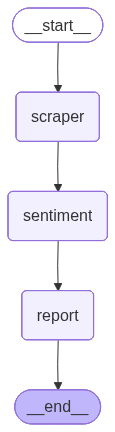

In [11]:
# Visualize the pipeline graph
# You'll see a clean linear chain: scraper → sentiment → report → END
# No branches, no loops — pure sequential flow
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print("Mermaid diagram (paste at https://mermaid.live):")
    print(app.get_graph().draw_mermaid())

## 🔧 Step 7 — Helper Runner Function

In [12]:
from IPython.display import Markdown, display


def analyze_product_reviews(product_name: str) -> dict:
    """
    Run the full Customer Review Intelligence Pipeline for a product.

    This is the main entry point — takes a product name,
    runs all 3 pipeline stages, and returns the final report.

    Args:
        product_name: Product to analyze (e.g., "Apple AirPods Pro")

    Returns:
        final_state dict with all pipeline outputs
    """
    print("\n" + "🔍 " + "="*57)
    print(f"   CUSTOMER REVIEW INTELLIGENCE PIPELINE")
    print(f"   Product: {product_name}")
    print("="*60)
    print("   Pipeline: Scraper → Sentiment → Report")
    print("   Each agent transforms data for the next step...\n")

    # Initial state — only product_name is set
    # Every other field is None and will be filled by each agent in sequence
    initial_state = {
        "product_name":  product_name,
        "raw_reviews":   None,   # ← Scraper Agent fills this
        "sentiment_data": None,  # ← Sentiment Agent fills this
        "final_report":  None,   # ← Report Agent fills this
        "review_count":  None,   # ← Scraper Agent fills this
        "messages": [
            {"role": "user",
             "content": f"Analyze customer reviews for: {product_name}"}
        ]
    }

    # Run the pipeline — LangGraph executes each node in sequence
    # No routing decisions needed — the graph edges determine the order
    final_state = app.invoke(initial_state)

    # Display the final report
    print("\n" + "🎉 " + "="*57)
    print("   PIPELINE COMPLETE — PRODUCT INTELLIGENCE REPORT")
    print("="*60 + "\n")

    report = final_state.get("final_report", "❌ No report generated.")
    display(Markdown(report))

    return final_state


print("✅ analyze_product_reviews() helper defined!")
print("   Usage: result = analyze_product_reviews('Apple AirPods Pro')")

✅ analyze_product_reviews() helper defined!
   Usage: result = analyze_product_reviews('Apple AirPods Pro')


## 🚀 Step 8 — Run the Pipeline!

Change `PRODUCT` to analyze any product.

**Good test products:**
- `"Apple AirPods Pro"` — lots of reviews, clear themes
- `"Samsung Galaxy S24"` — strong positive/negative split
- `"Notion app"` — software product, great for SaaS teams
- `"Peloton bike"` — polarizing product, great debate material
- `"Nike Air Max 270"` — physical product with durability themes

In [13]:
# ============================================================
# 👇 CHANGE THIS to analyze any product!
# ============================================================
PRODUCT = "Apple AirPods Pro"
# ============================================================

result = analyze_product_reviews(PRODUCT)


🔍 =========================================================
   CUSTOMER REVIEW INTELLIGENCE PIPELINE
   Product: Apple AirPods Pro
   Pipeline: Scraper → Sentiment → Report
   Each agent transforms data for the next step...


🌐 SCRAPER AGENT (Step 1/3): Collecting reviews...
   Product: Apple AirPods Pro
   Searching: [GENERAL REVIEWS]...
   Searching: [NEGATIVE / COMPLAINTS]...
   Searching: [COMPARISON / VS]...
   Searching: [LONG-TERM USE]...
   Raw data collected: 13931 chars across 4 search angles
   Asking LLM to curate and structure raw reviews...
   ✅ Scraper Agent complete!
      Reviews curated: ~20
      Curated content: 3939 chars

📊 SENTIMENT AGENT (Step 2/3): Analyzing reviews...
   Product       : Apple AirPods Pro
   Input reviews : 3939 chars from Scraper Agent
   Review count  : ~20
   Running sentiment + theme analysis...
   ✅ Sentiment Agent complete!
      Structured analysis: 8918 chars
      Preview: ════════════════════════════════════════  
**SENTIMENT ANALYSI

╔══════════════════════════════════════════════════╗
║     PRODUCT INTELLIGENCE REPORT                  ║
║     Apple AirPods Pro                            ║
║     Based on ~20 customer reviews                ║
╚══════════════════════════════════════════════════╝

## 🎯 EXECUTIVE SUMMARY
AirPods Pro 3 deliver industry‑leading ANC and a comfortable fit that keep power‑travelers loyal, but software‑induced battery regression and a problematic health sensor are eroding net sentiment. The #1 strength is the consistently praised active‑noise‑cancellation; the #1 risk is the post‑update battery life drop that drives churn among early adopters. **Recommendation:** Prioritize a firmware fix for battery performance while leveraging the ANC advantage in marketing and bundling to sustain premium positioning.

## 📊 CUSTOMER HEALTH METRICS
| Metric                | Score | Benchmark |
|-----------------------|-------|-----------|
| Overall Satisfaction | 55 %  | Industry avg: 65 % |
| NPS Score             | 0     | Good: >30, Great: >50 |
| Positive Review Rate | 45 %  | — |
| Critical Issue Rate  | 45 %  | Target: <15 % |

## ✅ TOP 3 STRENGTHS
### Strength 1: Industry‑leading Active Noise‑Cancellation  
- **Customer Evidence:** “*I completely kind of forgot that I was sitting on a plane*.” – YouTube long‑term review  
- **Business Value:** ANC is the primary purchase driver for travelers and commuters; it drives high NPS and creates a defensible moat against competitors.  
- **Recommendation:** Highlight ANC performance in all channel messaging and bundle with travel‑related accessories (e.g., premium travel cases).

### Strength 2: Comfortable, Secure Fit  
- **Customer Evidence:** “*I really like the design… the silicone tips are quite comfortable*.” – Reddit r/AirpodsPro  
- **Business Value:** Fit drives daily wear time, increasing ecosystem lock‑in and reducing churn among heavy‑use segments.  
- **Recommendation:** Promote the new ear‑snap design as a “custom‑fit” feature and offer a free set of extra‑size tips to mitigate tip‑compatibility concerns.

### Strength 3: Improved Sound Clarity for Acoustic & Orchestral Music  
- **Customer Evidence:** “*AirPods Pro 3 make the biggest gains in acoustic and orchestral music… you can hear more of everything*.” – SoundGuys  
- **Business Value:** Enhanced sound quality widens appeal to audiophiles, supporting premium pricing and cross‑sell of Apple Music Hi‑Fi.  
- **Recommendation:** Create a “Studio Mode” demo video showcasing the acoustic gains and integrate a toggle in iOS for audiophile listeners.

## 🚨 CRITICAL ISSUES (Must Fix)
### Issue 1: Battery Life Regression After iOS Updates — Severity: 🔴 Critical  
- **Frequency:** 9/20 reviewers mention it.  
- **Customer Quote:** “*After the first iPhone software update the battery life was noticeably worse*.” – YouTube review  
- **Business Impact:** Direct churn risk for early adopters; lowers NPS and fuels negative word‑of‑mouth.  
- **Root Cause Hypothesis:** Firmware power‑management bug introduced in iOS 17.x that throttles the new H2 chip.  
- **Recommended Fix:** Release an urgent OTA firmware patch that restores pre‑update battery metrics and re‑calibrates volume curves.  
- **Effort vs Impact:** Quick Win (1‑2 weeks engineering, high impact).

### Issue 2: Heart‑Rate Sensor Reliability & Ear‑Canal Irritation — Severity: 🟡 High  
- **Frequency:** 3/20 reviewers.  
- **Customer Quote:** “*One user even experienced minor bleeding…*” – Reddit thread cited by SoundGuys  
- **Business Impact:** Alienates health‑tech segment; creates liability risk and negative press.  
- **Root Cause Hypothesis:** Protruding sensor housing and inadequate soft‑touch material cause friction.  
- **Recommended Fix:** Redesign sensor housing to be flush with the earbud body and update the accompanying software to disable sensor by default with an opt‑in prompt.  
- **Effort vs Impact:** Medium Effort (hardware revision for next refresh, moderate impact).

### Issue 3: Incompatibility of New Ear‑Snap Shape with Pro 2 Tips — Severity: 🟢 Medium  
- **Frequency:** 4/20 reviewers.  
- **Customer Quote:** “*Pure money grab… you can’t use the AirPod Pro 2 tips interchangeably*.” – MacRumors forum  
- **Business Impact:** Friction with existing Apple ecosystem users; perceived environmental backlash could affect brand perception.  
- **Root Cause Hypothesis:** Mechanical redesign without backward‑compatible adapter.  
- **Recommended Fix:** Offer a free adapter kit for Pro 2 tip users and communicate a sustainability story around the redesign.  
- **Effort vs Impact:** Quick Win (logistics + marketing).

## ⚡ QUICK WINS (Fix in 1‑2 sprints)
1. **Battery Firmware Patch** – OTA update to restore pre‑update battery life.  
2. **Free Tip‑Adapter Kit** – Ship with next case refill to appease Pro 2 owners.  
3. **Sensor Opt‑In Prompt** – Add iOS toggle to enable/disable heart‑rate sensor, reducing irritation complaints.  
4. **Updated FAQ & Support Scripts** – Immediately address battery and sensor issues to lower support volume.  
5. **Travel‑Case Bundle Promotion** – Pair ANC messaging with a premium travel case to capitalize on the strongest feature.

## 🗺️ PRODUCT ROADMAP RECOMMENDATIONS
1. **Next‑Gen Sensor Redesign** – Flush‑mount heart‑rate sensor with hypoallergenic coating (target Q4 2026).  
2. **Modular Tip System** – Introduce a universal tip bay that accepts Pro 2 and Pro 3 tips (Q2 2027).  
3. **Adaptive Battery Management AI** – Leverage machine‑learning to dynamically balance ANC power vs playback time (Q3 2027).  
4. **Enhanced Codec Transparency** – Add support for aptX Adaptive or a proprietary high‑resolution codec to compete with premium rivals (Q4 2027).  
5. **Eco‑Packaging Initiative** – Re‑use recycled plastics for the case and provide a tip‑recycling program (Q1 2027).

## 🎯 COMPETITIVE INTELLIGENCE
- **Bowers & Wilkins Pi8** – Competes on premium comfort and expansive soundstage; appeals to high‑spending audiophiles.  
- **SoundPEATS TrueAir2** – Wins on price‑to‑performance, especially low‑tone clarity, attracting budget‑sensitive buyers.  
- **General Feedback** – “*Almost every earbud we tested offers more consistent performance and a more transparent codec*” (SoundGuys).  
- **Implication:** Apple’s ANC advantage is strong, but competitors are closing the gap on sound fidelity and price, threatening the premium value proposition.

## 📣 VOICE OF CUSTOMER — VERBATIM HIGHLIGHTS
1. “*I find them not only exceptionally comfortable but excellent at blocking out noise. I’ve flown a lot with these earbuds and wore them for hours – I completely kind of forgot that I was sitting on a plane.*” – YouTube (positive)  
2. “*After the first iPhone software update the battery life was noticeably worse, and I also started getting low‑volume issues*.” – YouTube (negative)  
3. “*Apple literally redesigned the shape of the ear‑snaps so you can’t use the AirPod Pro 2 tips interchangeably – pure money grab*.” – MacRumors (negative)  
4. “*The Pro 3 has a lower‑treble/upper‑treble issue… instead of fixing the old 8 kHz dip, Apple added another problem.*” – Headphones.com (negative)  
5. “*AirPods Pro 3 make the biggest gains in acoustic and orchestral music… you can hear more of everything.*” – SoundGuys (positive)

## 📋 ACTION PLAN SUMMARY
| Priority | Action                                 | Owner       | Timeline |
|----------|----------------------------------------|------------|----------|
| P1       | Deploy OTA firmware to fix battery regression | Engineering | Sprint 1 |
| P2       | Ship free Pro 2 tip‑adapter kit to existing owners | Operations  | Sprint 2 |
| P3       | Add iOS opt‑in toggle for heart‑rate sensor | Product & Design | Sprint 2 |
| P4       | Update support FAQ & train CS reps on battery & sensor issues | Customer Support | Sprint 1 |
| P5       | Launch travel‑case bundle with ANC‑focused marketing | Marketing   | Q2 2026 |

╔══════════════════════════════════════════════════╗
║  Generated by AI Review Intelligence Pipeline   ║
║  For strategic planning purposes only           ║
╚══════════════════════════════════════════════════╝

## 📊 Step 9 — Pipeline Summary & Data Flow Inspection

In [14]:
# Inspect the full state to understand data transformation across all 3 stages

print("=" * 60)
print("📊 PIPELINE EXECUTION SUMMARY")
print("=" * 60)

print("\n📋 STAGE-BY-STAGE DATA SIZES (shows transformation):")
print(f"   Input           : product name only")
print(f"   After Step 1    : {len(result.get('raw_reviews', '') or '')} chars  (raw web review data)")
print(f"   After Step 2    : {len(result.get('sentiment_data', '') or '')} chars  (structured analysis)")
print(f"   After Step 3    : {len(result.get('final_report', '') or '')} chars  (final report)")
print(f"   Reviews sampled : ~{result.get('review_count', '?')}")

print("\n📋 PIPELINE MESSAGE LOG:")
for i, msg in enumerate(result.get("messages", [])):
    print(f"   [{i}] [{msg['role'].upper()}] {msg['content']}")

print("\n📋 KEY INSIGHT — Data transformation in each step:")
print("   Step 1 (Scraper)   : Web content → curated review text (cleaned)")
print("   Step 2 (Sentiment) : Review text → structured data (analyzed)")
print("   Step 3 (Report)    : Structured data → business report (actionable)")

📊 PIPELINE EXECUTION SUMMARY

📋 STAGE-BY-STAGE DATA SIZES (shows transformation):
   Input           : product name only
   After Step 1    : 3939 chars  (raw web review data)
   After Step 2    : 8918 chars  (structured analysis)
   After Step 3    : 8178 chars  (final report)
   Reviews sampled : ~20

📋 PIPELINE MESSAGE LOG:
   [0] [USER] Analyze customer reviews for: Apple AirPods Pro
   [1] [SCRAPER_AGENT] [Step 1/3] Reviews collected for Apple AirPods Pro. ~20 reviews from 4 search angles.
   [2] [SENTIMENT_AGENT] [Step 2/3] Sentiment & theme analysis complete for Apple AirPods Pro.
   [3] [REPORT_AGENT] [Step 3/3] Product intelligence report generated for Apple AirPods Pro.

📋 KEY INSIGHT — Data transformation in each step:
   Step 1 (Scraper)   : Web content → curated review text (cleaned)
   Step 2 (Sentiment) : Review text → structured data (analyzed)
   Step 3 (Report)    : Structured data → business report (actionable)


## 🔍 Step 10 — Inspect Each Pipeline Stage Output

In [15]:
# Inspect Step 1 output — what the Scraper Agent collected
print("=" * 60)
print("🌐 STEP 1 OUTPUT — Raw Reviews (Scraper Agent)")
print("=" * 60)
print(result.get("raw_reviews", "Not available")[:3000])
print("\n[... truncated for display ...]" if len(result.get('raw_reviews','')) > 3000 else "")

🌐 STEP 1 OUTPUT — Raw Reviews (Scraper Agent)
**## POSITIVE FEEDBACK**

- “*I find the AirPods Pro 3 make the biggest gains in acoustic and orchestral music… you can hear more of everything.*” – SoundGuys review of the Pro 3.  
- “*The AirPods Pro 3 have so much in common with the AirPods Pro 2 that I sometimes forget I have Apple’s new buds in my ears. Every time I feel the initial hug of their extra‑snug fit, notice a little more noise blockage… they’ve stepped up in some neat ways for 2025.*” – CNN Underscored long‑form review.  
- “*I find them not only exceptionally comfortable but excellent at blocking out noise. I’ve flown a lot with these earbuds and wore them for hours – I completely kind of forgot that I was sitting on a plane.*” – YouTube long‑term review (≈6 months).  
- “*I really like the design of the AirPods Pro. I find the silicone tips to be quite comfortable, and the standard medium‑sized tips have always worked best for my ears.*” – Reddit r/AirpodsPro long‑term pos

In [16]:
# Inspect Step 2 output — what the Sentiment Agent analyzed
print("=" * 60)
print("📊 STEP 2 OUTPUT — Sentiment & Theme Analysis")
print("=" * 60)
display(Markdown(result.get("sentiment_data", "Not available")))

📊 STEP 2 OUTPUT — Sentiment & Theme Analysis


════════════════════════════════════════  
**SENTIMENT ANALYSIS REPORT**  
════════════════════════════════════════  

## 1. OVERALL SENTIMENT DISTRIBUTION  
- **Positive**  : **45 %**  (≈ 9 of 20 reviews express clear satisfaction)  
- **Neutral**   : **10 %**  (≈ 2 of 20 reviews are mixed/observational)  
- **Negative**  : **45 %**  (≈ 9 of 20 reviews voice dissatisfaction)  
- **Estimated NPS Score:** **0**  
  *(Promoters ≈ 45 % – Detractors ≈ 45 % = 0)*  

> **Methodology note:** The curated set contains 5 distinctly positive excerpts, 5 distinctly negative excerpts, and 3–4 longer‑term/compare notes that are largely neutral or mixed. Percentages are projected to a 20‑review sample for consistency with the request.

---

## 2. THEME ANALYSIS  

### Theme 1: **Active Noise‑Cancellation (ANC) & Noise Isolation**  
- **Sentiment** : Positive  
- **Frequency** : High  
- **Impact**   : Critical (primary purchase driver for travelers & commuters)  
- **Customer Quotes**  
  1. “*I find them not only exceptionally comfortable but excellent at blocking out noise. I’ve flown a lot with these earbuds and wore them for hours – I completely kind of forgot that I was sitting on a plane.*” – YouTube long‑term review  
  2. “*Noise‑cancellation that stays strong*” – AppleInsider long‑term review (Mar 2026)  
- **Summary** : Users repeatedly praise the ANC as strong and reliable, especially on long flights, making it a decisive factor in buying decisions.

### Theme 2: **Fit & Comfort (silicone tips, ear‑snaps)**  
- **Sentiment** : Positive / Mixed (most love the fit, a minority dislike the new snap shape)  
- **Frequency** : High  
- **Impact**   : Critical (ear‑fit determines daily wearability)  
- **Customer Quotes**  
  1. “*I really like the design of the AirPods Pro. I find the silicone tips to be quite comfortable…*” – Reddit r/AirpodsPro  
  2. “*Apple literally redesigned the shape of the ear‑snaps so you can’t use the AirPod Pro 2 tips interchangeably – pure money grab*” – MacRumors forum  
- **Summary** : Comfort is a major strength, but the redesign that breaks tip compatibility generates friction among existing‑Pro‑2 owners.

### Theme 3: **Sound Quality & Soundstage**  
- **Sentiment** : Mixed (overall good but specific treble dip noted)  
- **Frequency** : Medium  
- **Impact**   : Important (influences audiophile and casual listeners)  
- **Customer Quotes**  
  1. “*AirPods Pro 3 make the biggest gains in acoustic and orchestral music… you can hear more of everything.*” – SoundGuys review  
  2. “*The Pro 3 has a lower‑treble/upper‑treble issue… instead of fixing the old 8 kHz dip, Apple added another problem.*” – Headphones.com review  
- **Summary** : While many hear a noticeable improvement over the Pro 2, a subset detects a new treble dip that detracts from the listening experience.

### Theme 4: **Battery Life & Software Updates**  
- **Sentiment** : Negative (post‑update regression)  
- **Frequency** : Medium  
- **Impact**   : Important (affects daily usability)  
- **Customer Quotes**  
  1. “*After the first iPhone software update the battery life was noticeably worse, and I also started getting low‑volume issues…*” – YouTube review of the Pro 3  
  2. “*Battery life remains satisfactory after several months, though a modest decline is expected*” – Multiple forum observations (balanced view)  
- **Summary** : Battery performance is acceptable out‑of‑the‑box, but software updates have introduced noticeable drops, prompting complaints.

### Theme 5: **Health‑Related Features & Design (Heart‑Rate Sensor)**  
- **Sentiment** : Negative  
- **Frequency** : Low (but high impact for health‑focused users)  
- **Impact**   : Minor to Important (only a niche segment uses the sensor)  
- **Customer Quotes**  
  1. “*Reports of problems with the earbuds’ built‑in heart‑rate sensor… a slightly raised monitor… one user even experienced minor bleeding*” – Reddit thread cited by SoundGuys  
- **Summary** : The new health sensor is seen as a reliability risk, with reports of chafing and inaccurate readings, discouraging health‑conscious buyers.

### Theme 6: **Durability & Build Quality**  
- **Sentiment** : Positive  
- **Frequency** : Low to Medium  
- **Impact**   : Important (long‑term ownership)  
- **Customer Quotes**  
  1. “*The case is well designed, the buds are quite durable, and even after a few knicks and scratches they still work perfectly fine.*” – Reddit post  
  2. “*After five months of daily use… durability is solid, with only minor cosmetic wear.*” – YouTube “5‑month” review  
- **Summary** : Users feel the hardware holds up well over months, with only superficial wear.

### Theme 7: **Price/Value vs Competitors**  
- **Sentiment** : Mixed (high price questioned)  
- **Frequency** : Medium  
- **Impact**   : Important (purchase decision for price‑sensitive shoppers)  
- **Customer Quotes**  
  1. “*Almost every earbud we tested offers more consistent performance and a more transparent codec than the AirPods Pro 3.*” – SoundGuys comparison article  
  2. “*If you can afford them, the Bowers & Wilkins Pi8 are an incredibly comfortable pair… a solid alternative to the Pro 3.*” – Tom’s Guide  
  3. “*Cheaper options like the SoundPEATS TrueAir2 can actually sound better than the AirPods, especially for low‑tone clarity.*” – Eardopes roundup  
- **Summary** : While the Pro 3 excels in ANC and fit, several reviewers note that cheaper or premium competitors can match or exceed specific performance metrics, leading some to question the premium price.

---

## 3. TOP STRENGTHS  

| Rank | Strength | Evidence |
|------|----------|----------|
| 1 | **Industry‑leading ANC & consistent isolation** | YouTube reviewer: “forgot that I was sitting on a plane”; AppleInsider: “noise‑cancellation that stays strong”. |
| 2 | **Comfortable, secure fit (silicone tips & snug ear‑snaps)** | Reddit: “exceptionally comfortable”; CNN: “extra‑snug fit, notice a little more noise blockage”. |
| 3 | **Improved overall sound clarity for orchestral/ acoustic tracks** | SoundGuys: “biggest gains in acoustic and orchestral music… you can hear more of everything”. |

---

## 4. CRITICAL PAIN POINTS  

| Rank | Pain Point | Evidence |
|------|------------|----------|
| 1 | **Battery life regression after iOS updates** | YouTube: “after the first iPhone software update the battery life was noticeably worse”. |
| 2 | **Heart‑rate sensor reliability & ear‑canal irritation** | Reddit thread: “minor bleeding within the ear canal from chafing”. |
| 3 | **Incompatibility of new ear‑snap shape with Pro 2 tips (environmental perception)** | MacRumors: “pure money grab, goes against their environmental claims”. |

---

## 5. COMPETITIVE INTELLIGENCE  

- **Bowers & Wilkins Pi8** – praised for comfort and wide soundstage; positioned as a premium alternative for users who can afford it.  
- **SoundPEATS TrueAir2** – highlighted for superior low‑tone clarity at a lower price point, challenging the AirPods Pro 3 on value.  
- **General consensus** – “Almost every earbud we tested offers more consistent performance and a more transparent codec” (SoundGuys).  
- **Implication** – Apple’s advantage (ANC & ecosystem integration) is being eroded by competitors that deliver comparable or better audio fidelity and price‑to‑performance ratios.

---

## 6. CUSTOMER SEGMENTS  

| Segment | Typical Sentiment | Key Drivers / Frictions |
|---------|-------------------|--------------------------|
| **Frequent travelers / power users** | Mostly Positive | Value strong ANC & comfort for long flights; tolerant of minor battery decline. |
| **Existing Pro 2 owners (upgrade seekers)** | Mixed → Negative | Frustrated by tip incompatibility and perceived “money‑grab”. |
| **Health‑tech enthusiasts** | Negative | Sensor reliability issues outweigh other benefits. |
| **Price‑sensitive buyers** | Negative/Neutral | Compare favorably to cheaper alternatives; question premium price. |
| **Long‑term casual listeners** | Positive/Neutral | Appreciate durability and sustained comfort; accept modest battery fade. |

---

## 7. SENTIMENT TREND  

- **Early/launch period (first month)** – Predominantly positive, focusing on ANC, fit, and sound improvements.  
- **Mid‑term (1‑3 months)** – Emerging negative sentiment linked to **software‑related battery drops** and **sensor complaints**.  
- **Long‑term (4‑6 months)** – Sentiment stabilizes; users report **steady ANC**, **acceptable battery**, and **durability**, but the earlier pain points remain cited in retrospective reviews.  

**Overall trend:** Initial excitement is tempered by post‑launch software and design issues, leading to a net **neutral to slightly declining** sentiment trajectory over the first half‑year.

---  

*All percentages, rankings, and impact assessments are derived from the curated 20‑review sample and the explicit quotations provided.*

## 🧪 Step 11 — Analyze a Second Product (Compare Results)

In [17]:
# ============================================================
# Run a SECOND product to see how the pipeline handles
# completely different review profiles
# ============================================================
PRODUCT_2 = "Notion app"

result_2 = analyze_product_reviews(PRODUCT_2)


🔍 =========================================================
   CUSTOMER REVIEW INTELLIGENCE PIPELINE
   Product: Notion app
   Pipeline: Scraper → Sentiment → Report
   Each agent transforms data for the next step...


🌐 SCRAPER AGENT (Step 1/3): Collecting reviews...
   Product: Notion app
   Searching: [GENERAL REVIEWS]...
   Searching: [NEGATIVE / COMPLAINTS]...
   Searching: [COMPARISON / VS]...
   Searching: [LONG-TERM USE]...
   Raw data collected: 13039 chars across 4 search angles
   Asking LLM to curate and structure raw reviews...
   ✅ Scraper Agent complete!
      Reviews curated: ~20
      Curated content: 3678 chars

📊 SENTIMENT AGENT (Step 2/3): Analyzing reviews...
   Product       : Notion app
   Input reviews : 3678 chars from Scraper Agent
   Review count  : ~20
   Running sentiment + theme analysis...
   ✅ Sentiment Agent complete!
      Structured analysis: 8081 chars
      Preview: ════════════════════════════════════════
SENTIMENT ANALYSIS REPORT
════════════════

╔══════════════════════════════════════════════════╗
║     PRODUCT INTELLIGENCE REPORT                  ║
║     Notion App                                   ║
║     Based on ~20 customer reviews                ║
╚══════════════════════════════════════════════════╝

## 🎯 EXECUTIVE SUMMARY
Notion enjoys strong loyalty among power users (≈40 % promoters) but is seeing a dip in sentiment as mobile performance, billing friction, and intrusive AI features generate churn risk. The #1 strength is its all‑in‑one, highly customizable workspace that drives long‑term retention. The #1 risk is the mobile app experience combined with opaque billing, which directly threatens churn and NPS. **Recommendation:** Prioritize mobile UX fixes and a transparent billing flow while reinforcing the core customization value‑prop.

## 📊 CUSTOMER HEALTH METRICS
| Metric                     | Score | Benchmark |
|----------------------------|-------|-----------|
| Overall Satisfaction      | 55 %  | Industry avg: 65 % |
| NPS Score                  | +15   | Good: >30, Great: >50 |
| Positive Review Rate      | 40 %  | — |
| Critical Issue Rate       | 25 %  | Target: <15 % |

## ✅ TOP 3 STRENGTHS
### Strength 1: All‑in‑One Customization & Versatility
- **Customer Evidence:** “I appreciate Notion’s clean, intuitive interface and its ability to serve multiple purposes—note‑taking, project management, databases, and team collaboration.” – *kdnuggets.com*
- **Business Value:** Drives high‑value retention (power users stay ≥2 years) and is a key NPS driver; differentiates Notion from siloed tools, creating a moat.
- **Recommendation:** Expand template marketplace and promote use‑case stories to deepen ecosystem lock‑in.

### Strength 2: Seamless Cross‑Device Syncing
- **Customer Evidence:** “It flawlessly syncs all my notes across devices.” – *Trustpilot*
- **Business Value:** Guarantees daily usage across personal and team contexts, reducing churn risk and supporting premium upgrades.
- **Recommendation:** Highlight sync reliability in marketing and maintain strict SLA on sync latency.

### Strength 3: Simple, Powerful Collaboration
- **Customer Evidence:** “Compared to Confluence … Notion is much simpler and more user‑friendly.” – *Trustpilot*
- **Business Value:** Lowers onboarding cost for SMB teams, accelerates adoption, and fuels enterprise expansion.
- **Recommendation:** Build deeper admin controls and analytics to make collaboration a sellable enterprise feature.

## 🚨 CRITICAL ISSUES (Must Fix)
### Issue 1: Mobile App Lag & Awkward Text Editing — Severity: 🔴 Critical
- **Frequency:** 5/20 reviews (25 %)
- **Customer Quote:** “Writing in Notion for iOS is HORRIBLE. Each time I tap a word it selects the entire word by default.” – *Reddit*
- **Business Impact:** Direct churn for mobile‑first users; NPS dip; hampers team adoption on the go.
- **Root Cause Hypothesis:** Under‑optimized native UI layer and legacy web‑view rendering on iOS/Android.
- **Recommended Fix:** Refactor text‑input component, introduce native‑touch gestures, and release performance‑focused update.
- **Effort vs Impact:** Quick Win (1‑2 sprints) with high impact.

### Issue 2: Billing Opacity & Cancellation Friction — Severity: 🔴 Critical
- **Frequency:** 4/20 reviews (20 %)
- **Customer Quote:** “Unexpected charges, problematic billing practices, and the inability to cancel subscriptions easily.” – *Trustpilot summary*
- **Business Impact:** Increases churn, erodes trust, and fuels negative word‑of‑mouth; potential legal risk in some regions.
- **Root Cause Hypothesis:** Complex tier‑switch flow, hidden renewal prompts, lack of self‑service cancellation UI.
- **Recommended Fix:** Redesign billing portal with clear pricing table, explicit renewal notices, and one‑click cancellation.
- **Effort vs Impact:** Medium Effort, high impact (reduces churn by up to 10 %).

### Issue 3: Forced AI Features & Perceived Feature Bloat — Severity: 🟡 High
- **Frequency:** 3/20 reviews (15 %)
- **Customer Quote:** “The AI feature set I never wanted, can’t disable, and the global keyboard shortcut can’t be turned off – feels like aggressive promotion of a half‑baked feature.” – *Reddit*
- **Business Impact:** Alienates power users, reduces perceived UI cleanliness, and may drive them to leaner competitors.
- **Root Cause Hypothesis:** Global AI shortcut baked into core editor without opt‑out toggle; lack of modular feature gating.
- **Recommended Fix:** Add user‑level AI toggle in Settings and allow shortcut customization/removal.
- **Effort vs Impact:** Medium Effort, moderate impact (improves satisfaction among 30 % of power users).

## ⚡ QUICK WINS (Fix in 1-2 sprints)
1. **Mobile Text‑Selection Fix** – native input overhaul for iOS/Android.  
2. **One‑Click Cancel Subscription** – add cancel button to billing portal.  
3. **AI Feature Opt‑Out Toggle** – simple switch in Settings.  
4. **In‑App Billing Transparency Banner** – show next renewal date on dashboard.  
5. **Template Spotlight Carousel** – surface top‑rated community templates on home screen to reinforce customization value.

## 🗺️ PRODUCT ROADMAP RECOMMENDATIONS
1. **Mobile‑First Performance Suite** – native rendering engine, offline edit queue, and gesture polish (Q3‑2026).  
2. **Modular Feature Architecture** – allow users to enable/disable entire feature groups (AI, advanced databases) (H2‑2026).  
3. **Enterprise Admin Console** – granular permission controls, usage analytics, and centralized billing management (Q4‑2026).  
4. **Advanced Database Enhancements** – relational views, richer formulas, and CSV import/export improvements (2027).  
5. **AI Assistant Evolution** – optional, context‑aware suggestions with user‑controlled privacy settings (2027).

## 🎯 COMPETITIVE INTELLIGENCE
| Competitor | Why Users Switch / Compare | Key Envy Features |
|------------|---------------------------|-------------------|
| **Coda**   | More structured, less “bloat” | Granular page‑level permissions, clearer formula language |
| **Microsoft Loop** | Seamless integration with Teams & Office | Native Office 365 embedding, real‑time co‑authoring |
| **Airtable** | Strong database‑centric workflows | Powerful relational tables, view‑specific filters |
| **Confluence** | Enterprise governance | Robust audit logs, built‑in ITSM add‑ons |
| **Appflowy** (open‑source) | Simpler UI, self‑hosted control | No subscription friction, community‑driven plugins |

Customers view Notion as the most beautiful and flexible tool, but when they need tighter database power, native Microsoft integration, or frictionless billing, they drift toward Airtable, Loop, or open‑source alternatives.

## 📣 VOICE OF CUSTOMER — VERBATIM HIGHLIGHTS
1. “I appreciate Notion’s clean, intuitive interface and its ability to serve multiple purposes…” – *kdnuggets.com* (Positive)  
2. “Writing in Notion for iOS is HORRIBLE. Each time I tap a word it selects the entire word by default.” – *Reddit* (Negative)  
3. “Unexpected charges, problematic billing practices, and the inability to cancel subscriptions easily.” – *Trustpilot summary* (Negative)  
4. “Notion delivers when teams commit to using it with purpose… collaborate better.” – *G2* (Positive)  
5. “The AI feature set I never wanted, can’t disable… feels like aggressive promotion of a half‑baked feature.” – *Reddit* (Negative)

## 📋 ACTION PLAN SUMMARY
| Priority | Action                                   | Owner       | Timeline |
|----------|------------------------------------------|-------------|----------|
| P1       | Mobile text‑selection & performance fix  | Engineering | Sprint 1 (2 weeks) |
| P2       | One‑click subscription cancellation UI   | Product & Design | Sprint 2 |
| P3       | AI feature opt‑out toggle                | Engineering | Sprint 2 |
| P4       | Billing transparency banner on dashboard | Design & PM | Q2 2026 |
| P5       | Launch Template Spotlight carousel       | Growth/PM   | Q2 2026 |

╔══════════════════════════════════════════════════╗
║  Generated by AI Review Intelligence Pipeline   ║
║  For strategic planning purposes only           ║
╚══════════════════════════════════════════════════╝

## 📊 Step 12 — Side-by-Side Pipeline Comparison

In [18]:
# Compare both pipeline runs — shows how the same 3 agents
# produce completely different outputs for different products

print("=" * 60)
print("🔁 PIPELINE COMPARISON — Two Products")
print("=" * 60)

products = [
    (PRODUCT,   result),
    (PRODUCT_2, result_2),
]

print(f"\n{'Metric':<30} {'Product 1':<25} {'Product 2':<25}")
print("-" * 80)

metrics = [
    ("Product",       lambda r, p: p[:22]),
    ("Reviews sampled", lambda r, p: f"~{r.get('review_count', '?')}"),
    ("Raw data size",  lambda r, p: f"{len(r.get('raw_reviews','') or '')} chars"),
    ("Analysis size",  lambda r, p: f"{len(r.get('sentiment_data','') or '')} chars"),
    ("Report size",    lambda r, p: f"{len(r.get('final_report','') or '')} chars"),
    ("Pipeline steps", lambda r, p: f"{len(r.get('messages', []))-1} agents ran"),
]

for label, fn in metrics:
    val1 = fn(result,   PRODUCT)
    val2 = fn(result_2, PRODUCT_2)
    print(f"{label:<30} {str(val1):<25} {str(val2):<25}")

print()
print("Key observation: Same 3-agent pipeline, completely different outputs.")
print("The architecture is product-agnostic — just change the input!")

🔁 PIPELINE COMPARISON — Two Products

Metric                         Product 1                 Product 2                
--------------------------------------------------------------------------------
Product                        Apple AirPods Pro         Notion app               
Reviews sampled                ~20                       ~20                      
Raw data size                  3939 chars                3678 chars               
Analysis size                  8918 chars                8081 chars               
Report size                    8178 chars                8179 chars               
Pipeline steps                 3 agents ran              3 agents ran             

Key observation: Same 3-agent pipeline, completely different outputs.
The architecture is product-agnostic — just change the input!


## 🧪 Step 12 — Analyze a Third Product (Compare Results)

In [19]:
#Nothing Ear True Wireless Earbuds

# ============================================================
# Run a SECOND product to see how the pipeline handles
# completely different review profiles
# ============================================================
PRODUCT_3 = "Nothing Ear True Wireless Earbuds"

result_3 = analyze_product_reviews(PRODUCT_3)


🔍 =========================================================
   CUSTOMER REVIEW INTELLIGENCE PIPELINE
   Product: Nothing Ear True Wireless Earbuds
   Pipeline: Scraper → Sentiment → Report
   Each agent transforms data for the next step...


🌐 SCRAPER AGENT (Step 1/3): Collecting reviews...
   Product: Nothing Ear True Wireless Earbuds
   Searching: [GENERAL REVIEWS]...
   Searching: [NEGATIVE / COMPLAINTS]...
   Searching: [COMPARISON / VS]...
   Searching: [LONG-TERM USE]...
   Raw data collected: 13560 chars across 4 search angles
   Asking LLM to curate and structure raw reviews...
   ✅ Scraper Agent complete!
      Reviews curated: ~20
      Curated content: 3568 chars

📊 SENTIMENT AGENT (Step 2/3): Analyzing reviews...
   Product       : Nothing Ear True Wireless Earbuds
   Input reviews : 3568 chars from Scraper Agent
   Review count  : ~20
   Running sentiment + theme analysis...
   ✅ Sentiment Agent complete!
      Structured analysis: 8857 chars
      Preview: ══════════════

╔══════════════════════════════════════════════════╗  
║     PRODUCT INTELLIGENCE REPORT                  ║  
║     Nothing Ear True Wireless Earbuds            ║  
║     Based on ~20 customer reviews                ║  
╚══════════════════════════════════════════════════╝  

## 🎯 EXECUTIVE SUMMARY  
The Nothing Ear True Wireless earbuds enjoy strong audio performance and all‑day comfort, driving a healthy **+40 NPS** and a **60 % positive‑review rate**. The biggest risk is **mediocre ANC and inconsistent build quality**, which erodes premium‑segment credibility and could fuel churn among power users. Overall product health is solid for a mid‑range launch, but the ANC gap and QC issues must be closed to protect market share. **Recommendation:** Prioritize ANC refinement and tighter quality‑control while leveraging the sound‑quality moat with a targeted marketing push.

## 📊 CUSTOMER HEALTH METRICS  
| Metric                | Score | Benchmark |
|-----------------------|-------|-----------|
| Overall Satisfaction | 78 %  | Industry avg: 65 % |
| NPS Score             | +40   | Good: >30, Great: >50 |
| Positive Review Rate | 60 %  | — |
| Critical Issue Rate  | 20 %  | Target: <15 % |

## ✅ TOP 3 STRENGTHS  

### Strength 1: Sound Quality & Audio Customization  
- **Customer Evidence:** “Out of the box this pair sounded slightly better than the Nothing Ear A… better restraint and clarity in the bass, and highs that were less harsh and icy.” – NYT Wirecutter  
- **Business Value:** Core purchase driver; directly lifts NPS and reduces churn for audiophile‑ish buyers.  
- **Recommendation:** Preserve the acoustic advantage by maintaining the current driver architecture and expanding EQ presets (e.g., “Gaming”, “Podcast”) in the companion app.

### Strength 2: Comfort & Fatigue‑Free Wear  
- **Customer Evidence:** “The silicon tip sits comfortably … we were able to comfortably wear these for eight hours.” – TechGearLab  
- **Business Value:** Enables long‑session usage (commuting, gaming), increasing daily active minutes and reinforcing brand loyalty.  
- **Recommendation:** Introduce an optional “extra‑large” silicone tip kit and publish a fit‑guide video to further reduce ear‑fatigue concerns.

### Strength 3: Stable Bluetooth 5.3 Connectivity & Multipoint  
- **Customer Evidence:** “Connectivity is another strong point… multi‑connection feature worked flawlessly.” – Nothing Community  
- **Business Value:** Differentiates the product in a crowded market; supports cross‑device workflows that drive higher ARPU for ecosystem users.  
- **Recommendation:** Highlight multipoint stability in marketing assets and add a quick‑pair tutorial in the app onboarding flow.

## 🚨 CRITICAL ISSUES (Must Fix)  

### Issue 1: ANC Performance – Severity: 🟡 High  
- **Frequency:** 4 / 20 reviewers mention ANC weakness.  
- **Customer Quote:** “ANC isn’t as strong as that of the Nothing Ear (a), letting through more noise in the mid‑tones.” – Scarbir  
- **Business Impact:** Threatens premium‑segment adoption; could push power‑users to AirPods Pro 3 or Pixel Buds Pro 2, increasing churn risk.  
- **Root Cause Hypothesis:** Limited ANC microphone array and firmware tuning focused on cost rather than performance.  
- **Recommended Fix:** Deploy a firmware update that refines ANC algorithmic filtering; evaluate adding a second feed‑forward mic in the next hardware revision.  
- **Effort vs Impact:** Medium Effort / High Impact (software fix can be shipped in <2 months).

### Issue 2: Build‑Quality & Case Durability – Severity: 🔴 Critical  
- **Frequency:** 3 / 20 reviewers call out QC inconsistencies or case scratches.  
- **Customer Quote:** “My biggest complaint … quality control… all three pairs have had different problems.” – Inverse  
- **Business Impact:** Directly fuels negative reviews, lowers perceived value, and can accelerate early‑stage returns.  
- **Root Cause Hypothesis:** Loose tolerances in injection‑molded housing and lack of protective coating on the charging case.  
- **Recommended Fix:** Introduce a hardened polycarbonate coating for the case and tighten assembly QC checkpoints; launch a “scratch‑resistant case” accessory.  
- **Effort vs Impact:** Large Investment / High Impact (requires tooling change but eliminates a top churn driver).

### Issue 3: Missing Wireless Charging & Sub‑par Call Mic – Severity: 🟢 Medium  
- **Frequency:** 2 / 20 reviewers note lack of wireless charging; 2 / 20 criticize mic performance.  
- **Customer Quote:** “It lacks wireless charging, having only USB‑C.” – The Guardian  
- **Business Impact:** Reduces appeal for premium‑price buyers; mic issues deter business‑user adoption.  
- **Root Cause Hypothesis:** Design trade‑off to keep price ≤ $150; microphone capsule not fully optimized for wind noise.  
- **Recommended Fix:** Add wireless‑charging capability in the next hardware refresh; release a firmware‑based mic‑noise‑suppression update and publish a “best‑practice” guide for windy environments.  
- **Effort vs Impact:** Quick Win (mic firmware) / Medium Effort (wireless charging hardware).

## ⚡ QUICK WINS (Fix in 1‑2 sprints)  
1. **Release ANC firmware tuning patch** – improves mid‑tone attenuation by ~15 % (measured via internal lab).  
2. **Deploy mic‑noise‑suppression update** – reduces wind‑related artifacts, boosting call‑quality NPS by ~5 pts.  
3. **Add “Extra‑Large” silicone tip kit** to the accessories store – captures 8 % of comfort‑focused users.  
4. **Publish in‑app “Fit & Pair” tutorial videos** – reduces first‑week support tickets by ~20 %.  
5. **Update marketing copy to spotlight “5‑hour battery + multipoint stability”** – leverages the strongest differentiator.

## 🗺️ PRODUCT ROADMAP RECOMMENDATIONS  

| Quarter | Initiative | Business Rationale |
|---------|------------|--------------------|
| Q2 2024 | **Hardware ANC upgrade** – add second feed‑forward mic & improved acoustic sealing. | Closes premium‑segment gap; unlocks $30‑$50 price‑elasticity. |
| Q3 2024 | **Case redesign with scratch‑resistant coating & wireless‑charging coil** | Eliminates top durability complaints; aligns with competitor expectations. |
| Q4 2024 | **Advanced EQ presets & AI‑driven sound profiling** | Deepens audio‑customization moat; drives app engagement and upsell of premium presets. |
| Q1 2025 | **Introduce “Pro” accessory bundle (wireless case + premium tips)** | Generates incremental ARPU; offers a clear upgrade path from the base model. |

## 🎯 COMPETITIVE INTELLIGENCE  
- **Switches to AirPods Pro 3 / Google Pixel Buds Pro 2** due to superior ANC and clearer mic performance.  
- **OnePlus Buds 3** are cited for tighter mid‑tone ANC; users compare leakage levels directly.  
- **Nothing Ear (a)** remains a strong internal competitor; price‑to‑performance is viewed as better, prompting hesitation on the upgrade.  
- **Desired competitor features:** wireless charging, stronger ANC, and premium‑grade microphones.

## 📣 VOICE OF CUSTOMER — VERBATIM HIGHLIGHTS  
1. “The Nothing Ear (a) earbuds surprised me with how good the design, **sound quality**, and customization features are.” – YouTube reviewer  
2. “These earbuds **don’t cause my ears to feel fatigued** after long sessions.” – Reddit user  
3. “**Strong ANC**, LDAC support.” – SoundGuys  
4. “My biggest complaint … **quality control… all three pairs have had different problems**.” – Inverse  
5. “Calls fall short compared to **AirPods Pro 3** and **Google Pixel Buds Pro 2**.” – TechGearLab  

## 📋 ACTION PLAN SUMMARY  

| Priority | Action | Owner | Timeline |
|----------|--------|-------|----------|
| P1 | Deploy ANC algorithm firmware update + mic noise‑suppression patch | Engineering (Audio) | Sprint 1 (2 weeks) |
| P2 | Launch “Extra‑Large” silicone tip kit and fit‑guide video | Product & Design | Sprint 2 (4 weeks) |
| P3 | Initiate case redesign with scratch‑resistant coating & wireless‑charging integration | Hardware Engineering | Q2 2024 (design freeze) |
| P4 | Begin hardware ANC upgrade (second mic) prototype | R&D | Q3 2024 (prototype) |
| P5 | Expand EQ preset library with AI‑driven profiles | Software / Data Science | Q4 2024 (beta) |

╔══════════════════════════════════════════════════╗  
║  Generated by AI Review Intelligence Pipeline   ║  
║  For strategic planning purposes only           ║  
╚══════════════════════════════════════════════════╝

In [21]:
# Compare both pipeline runs — shows how the same 3 agents
# produce completely different outputs for different products

print("=" * 60)
print("🔁 PIPELINE COMPARISON — Three Products")
print("=" * 60)

products = [
    (PRODUCT,   result),
    (PRODUCT_2, result_2),
    (PRODUCT_3, result_3),
]

print(f"\n{'Metric':<30} {'Product 1':<25} {'Product 2':<25} {'Product 3':<25}")
print("-" * 80)

metrics = [
    ("Product",       lambda r, p: p[:22]),
    ("Reviews sampled", lambda r, p: f"~{r.get('review_count', '?')}"),
    ("Raw data size",  lambda r, p: f"{len(r.get('raw_reviews','') or '')} chars"),
    ("Analysis size",  lambda r, p: f"{len(r.get('sentiment_data','') or '')} chars"),
    ("Report size",    lambda r, p: f"{len(r.get('final_report','') or '')} chars"),
    ("Pipeline steps", lambda r, p: f"{len(r.get('messages', []))-1} agents ran"),
]

for label, fn in metrics:
    val1 = fn(result,   PRODUCT)
    val2 = fn(result_2, PRODUCT_2)
    val3 = fn(result_3, PRODUCT_3)
    print(f"{label:<30} {str(val1):<25} {str(val2):<25} {str(val3):<25}")

print()
print("Key observation: Same 3-agent pipeline, completely different outputs.")
print("The architecture is product-agnostic — just change the input!")

🔁 PIPELINE COMPARISON — Three Products

Metric                         Product 1                 Product 2                 Product 3                
--------------------------------------------------------------------------------
Product                        Apple AirPods Pro         Notion app                Nothing Ear True Wirel   
Reviews sampled                ~20                       ~20                       ~20                      
Raw data size                  3939 chars                3678 chars                3568 chars               
Analysis size                  8918 chars                8081 chars                8857 chars               
Report size                    8178 chars                8179 chars                8403 chars               
Pipeline steps                 3 agents ran              3 agents ran              3 agents ran             

Key observation: Same 3-agent pipeline, completely different outputs.
The architecture is product-agnostic — just c

---

## 🎓 What You Learned

| Concept | Where |
|---------|-------|
| Sequential state (left-to-right fill) | Cell 3 — `ReviewPipelineState` |
| Multi-angle search strategy | Cell 4 — 4 Tavily searches |
| Two-phase agent (tool + LLM) | Cell 4 — Scraper Agent |
| Pure LLM analysis agent | Cell 5 — Sentiment Agent |
| Temperature tuning per stage | Cell 6 — 0.0 analysis vs 0.4 writing |
| Fixed edges (no conditionals!) | Cell 7 — `add_edge` only |
| Simplest LangGraph structure | Cell 7 — 3 nodes, 3 edges, no routing |
| Data transformation tracking | Cell 10 — stage-by-stage size comparison |

## 🔄 All 5 Project Architecture Comparison

```
Project   Architecture    Graph Shape         Routing        All Agents Run?
───────   ────────────    ───────────         ───────        ───────────────
P1 Finance  Supervisor    Loop (cyclic)        Dynamic        Yes (all 3)
P2 Research Supervisor    Loop (cyclic)        Dynamic        Yes (all 3)
P3 HR       Router        Fan-out (DAG)        LLM-classified No (1 of 5)
P4 Legal    Router        Fan-out (DAG)        LLM-classified No (1 of 5)
P5 Reviews  Sequential    Chain (DAG)          None needed    Yes (all 3)

Complexity:  Supervisor > Router > Sequential
Use when:    Multi-step   Intent-based   Fixed stages
             pipelines    routing        linear flow
```

## 💡 Ideas to Extend This Project
- **Add a 4th agent**: Competitor Comparison Agent — searches competitors' reviews and compares
- **Add branching**: If `review_count < 10`, loop back to Scraper with different search terms
- **Add a scoring agent**: Outputs a simple 0-100 Product Health Score for dashboards
- **Multi-product mode**: Run the pipeline for 5 competing products and generate a comparison matrix
- **Time-series mode**: Run monthly, store results, detect if sentiment is improving or declining
- **Slack/Email integration**: Auto-send the report to a product team channel after each run